# 第3回　MDP の最小例を理解する

## この notebook のゴール

1. **状態 $s$、行動 $a$、次状態 $s'$、報酬 $r$** の関係を理解する
2. **reward（即時報酬）と return（累積報酬）** の違いを理解する
3. 固定方策のもとで **状態価値 $V(s)$** を近似する考え方を体験する
4. MDP が「**状態遷移を持つ逐次意思決定問題**」であることを実感する

## バンディット問題との違い

バンディット問題では行動を選んでも「状態」は変化しませんでした。
MDP（Markov Decision Process）では、行動によって **次の状態 $s'$** が決まり、
そこからさらに行動を選ぶ — という **逐次的な意思決定** が発生します。
今回はもっとも単純な deterministic gridworld を使い、MDP の基本構造を体験します。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 環境の説明：4×4 Gridworld

下図のような 4×4 のグリッドワールドを使います。

```
 S  .  .  .          S = 開始状態 (0,0)
 .  .  .  .          G = ゴール状態 (3,3)
 .  .  .  .
 .  .  .  G
```

| 項目 | 内容 |
|------|------|
| 状態 $s$ | `(row, col)` のタプル。左上が `(0,0)`、右下が `(3,3)` |
| 行動 $a$ | `0`: 上、`1`: 右、`2`: 下、`3`: 左 |
| 遷移 | 決定的（deterministic）。グリッド外への移動はその場に留まる |
| 報酬 | ゴール到達時 $+1.0$、それ以外のステップ $-0.01$ |
| 終了条件 | ゴール到達 or ステップ上限 (`max_steps=30`) |

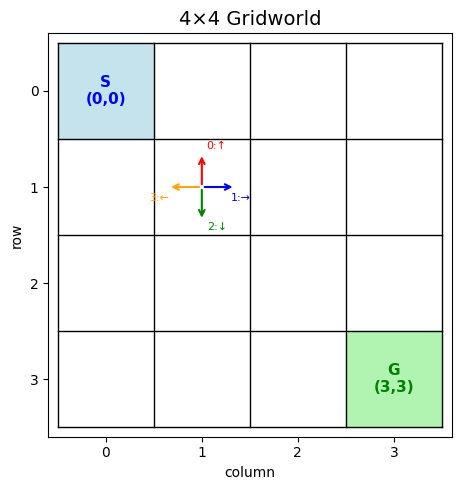

In [17]:
def plot_gridworld():
    '''4x4 gridworld の概要図を描画する。'''
    fig, ax = plt.subplots(figsize=(5, 5))
    for i in range(5):
        ax.plot([i, i], [0, 4], "k-", lw=1)
        ax.plot([0, 4], [i, i], "k-", lw=1)
    ax.add_patch(plt.Rectangle((0, 3), 1, 1, color="lightblue", alpha=0.7))
    ax.text(0.5, 3.5, "S\n(0,0)", ha="center", va="center", fontsize=11,
            fontweight="bold", color="blue")
    ax.add_patch(plt.Rectangle((3, 0), 1, 1, color="lightgreen", alpha=0.7))
    ax.text(3.5, 0.5, "G\n(3,3)", ha="center", va="center", fontsize=11,
            fontweight="bold", color="green")
    cx, cy = 1.5, 2.5
    ax.annotate("", xy=(cx, cy+0.35), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
    ax.text(cx+0.05, cy+0.4, "0:↑", fontsize=8, color="red")
    ax.annotate("", xy=(cx+0.35, cy), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
    ax.text(cx+0.3, cy-0.15, "1:→", fontsize=8, color="blue")
    ax.annotate("", xy=(cx, cy-0.35), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="->", color="green", lw=1.5))
    ax.text(cx+0.05, cy-0.45, "2:↓", fontsize=8, color="green")
    ax.annotate("", xy=(cx-0.35, cy), xytext=(cx, cy),
                arrowprops=dict(arrowstyle="->", color="orange", lw=1.5))
    ax.text(cx-0.55, cy-0.15, "3:←", fontsize=8, color="orange")
    ax.set_xlim(-0.1, 4.1)
    ax.set_ylim(-0.1, 4.1)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(0.5, 4, 1))
    ax.set_xticklabels([0, 1, 2, 3])
    ax.set_yticks(np.arange(0.5, 4, 1))
    ax.set_yticklabels([3, 2, 1, 0])
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    ax.set_title("4×4 Gridworld", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_gridworld()

## 環境クラスの実装：`SimpleGridMDP`

4×4 の deterministic gridworld を実装します。
主要なメソッドは以下の通りです。

- `reset(start_state)` — 環境を初期化する
- `step(action)` — 行動を受け取り `(next_state, reward, done)` を返す
- `render()` — 現在の状態をテキストで表示する
- `state_to_index(s)` / `index_to_state(idx)` — 状態とインデックスの変換

In [3]:
class SimpleGridMDP:
    '''4x4 deterministic gridworld.'''

    # 行動の定義
    ACTIONS = {0: (-1, 0),   # 上
               1: (0, 1),    # 右
               2: (1, 0),    # 下
               3: (0, -1)}   # 左
    ACTION_NAMES = {0: "↑", 1: "→", 2: "↓", 3: "←"}
    N_ACTIONS = 4
    ROWS, COLS = 4, 4
    GOAL = (3, 3)

    def __init__(self, start_state=(0, 0), max_steps=30,
                 step_reward=-0.01, goal_reward=1.0):
        self.start_state = start_state
        self.max_steps = max_steps
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.state = None
        self.steps = 0

    # ---- core API ----
    def reset(self, start_state=None):
        '''環境を初期化して開始状態を返す。'''
        if start_state is not None:
            self.start_state = start_state
        self.state = self.start_state
        self.steps = 0
        return self.state
    def step(self, action):
        '''行動を受け取り (next_state, reward, done) を返す。'''
        dr, dc = self.ACTIONS[action]
        r, c = self.state
        nr, nc = r + dr, c + dc
        # グリッド外に出る場合はその場に留まる
        if 0 <= nr < self.ROWS and 0 <= nc < self.COLS:
            next_state = (nr, nc)
        else:
            next_state = self.state
        self.state = next_state
        self.steps += 1
        if self.state == self.GOAL:
            return self.state, self.goal_reward, True
        if self.steps >= self.max_steps:
            return self.state, self.step_reward, True
        return self.state, self.step_reward, False
    # ---- utilities ----
    def state_to_index(self, s):
        '''(row, col) -> int'''
        return s[0] * self.COLS + s[1]

    def index_to_state(self, idx):
        '''int -> (row, col)'''
        return (idx // self.COLS, idx % self.COLS)

    @property
    def n_states(self):
        return self.ROWS * self.COLS

    def render(self):
        '''現在の状態をテキストで表示する。'''
        for r in range(self.ROWS):
            row_str = ""
            for c in range(self.COLS):
                if (r, c) == self.state:
                    row_str += " A "
                elif (r, c) == self.GOAL:
                    row_str += " G "
                else:
                    row_str += " . "
            print(row_str)
        print()

### 環境の動作確認

環境を作成し、いくつかの行動を試して正しく動くか確認します。

In [4]:
env = SimpleGridMDP()
s = env.reset()
print(f"開始状態: {s}")
env.render()

# 右 → 下 と移動してみる
for a_name, a in [("右", 1), ("下", 2)]:
    s, r, done = env.step(a)
    print(f"行動: {a_name} → 状態: {s}, 報酬: {r}, 終了: {done}")
env.render()

開始状態: (0, 0)
 A  .  .  . 
 .  .  .  . 
 .  .  .  . 
 .  .  .  G 

行動: 右 → 状態: (0, 1), 報酬: -0.01, 終了: False
行動: 下 → 状態: (1, 1), 報酬: -0.01, 終了: False
 .  .  .  . 
 .  A  .  . 
 .  .  .  . 
 .  .  .  G 



### Sanity check（自動テスト）

`step()` が正しく実装されているか簡単に確認します。

In [5]:
# --- sanity check ---
_env = SimpleGridMDP()
_env.reset(start_state=(0, 0))

# 上に移動 → 壁なのでその場に留まる
_s, _r, _d = _env.step(0)
assert _s == (0, 0), f"壁の処理が不正: {_s}"
assert _r == -0.01, f"step_reward が不正: {_r}"
assert not _d

# ゴールへ直接移動テスト
_env.reset(start_state=(3, 2))
_s, _r, _d = _env.step(1)  # 右 → (3,3)
assert _s == (3, 3), f"ゴール到達が不正: {_s}"
assert _r == 1.0, f"goal_reward が不正: {_r}"
assert _d, "ゴール到達なのに done=False"

print("✓ すべての sanity check をパスしました")

✓ すべての sanity check をパスしました


## 1エピソードを観察する

固定方策（ここではランダム方策）を使って1エピソードを生成し、
**状態 → 行動 → 次状態 → 報酬** の流れを確認します。

In [6]:
def generate_episode(env, policy, start_state=None, max_steps=None):
    '''固定方策で1エピソードを生成する。

    Parameters
    ----------
    env : SimpleGridMDP
    policy : callable — policy(state) -> action
    start_state : tuple or None
    max_steps : int or None

    Returns
    -------
    states, actions, rewards
    '''
    if max_steps is not None:
        env.max_steps = max_steps
    state = env.reset(start_state=start_state)
    states, actions, rewards = [state], [], []
    done = False
    while not done:
        action = policy(state)
        next_state, reward, done = env.step(action)
        actions.append(action)
        rewards.append(reward)
        states.append(next_state)
        state = next_state
    return states, actions, rewards

### ランダム方策で1エピソードを生成

ランダム方策（各状態で一様ランダムに行動を選ぶ）でエピソードを生成し、
状態遷移の様子を確認します。

In [7]:
# ランダム方策
rng = np.random.default_rng(42)
def random_policy(state):
    return rng.integers(0, SimpleGridMDP.N_ACTIONS)

env = SimpleGridMDP()
states, actions, rewards = generate_episode(env, random_policy)

print(f"エピソード長: {len(actions)} ステップ")
print(f"合計報酬 (total reward): {sum(rewards):.4f}")
print()
print("ステップ | 状態      | 行動 | 次状態    | 報酬")
print("-" * 50)
for t in range(len(actions)):
    a_name = SimpleGridMDP.ACTION_NAMES[actions[t]]
    print(f"  {t:3d}    | {str(states[t]):9s} | {a_name:2s}   | "
          f"{str(states[t+1]):9s} | {rewards[t]:+.2f}")

エピソード長: 30 ステップ
合計報酬 (total reward): -0.3000

ステップ | 状態      | 行動 | 次状態    | 報酬
--------------------------------------------------
    0    | (0, 0)    | ↑    | (0, 0)    | -0.01
    1    | (0, 0)    | ←    | (0, 0)    | -0.01
    2    | (0, 0)    | ↓    | (1, 0)    | -0.01
    3    | (1, 0)    | →    | (1, 1)    | -0.01
    4    | (1, 1)    | →    | (1, 2)    | -0.01
    5    | (1, 2)    | ←    | (1, 1)    | -0.01
    6    | (1, 1)    | ↑    | (0, 1)    | -0.01
    7    | (0, 1)    | ↓    | (1, 1)    | -0.01
    8    | (1, 1)    | ↑    | (0, 1)    | -0.01
    9    | (0, 1)    | ↑    | (0, 1)    | -0.01
   10    | (0, 1)    | ↓    | (1, 1)    | -0.01
   11    | (1, 1)    | ←    | (1, 0)    | -0.01
   12    | (1, 0)    | ↓    | (2, 0)    | -0.01
   13    | (2, 0)    | ←    | (2, 0)    | -0.01
   14    | (2, 0)    | ↓    | (3, 0)    | -0.01
   15    | (3, 0)    | ←    | (3, 0)    | -0.01
   16    | (3, 0)    | ↓    | (3, 0)    | -0.01
   17    | (3, 0)    | ↑    | (2, 0)    | -0.01
   18

## Reward と Return の違い

- **Reward（即時報酬）** $r_t$：各ステップで受け取る報酬
- **Return（累積報酬）** $G_t$：ステップ $t$ 以降の割引累積報酬

$$
G_t = r_{t+1} + \gamma \, r_{t+2} + \gamma^2 \, r_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k \, r_{t+k+1}
$$

ここで $\gamma \in [0, 1]$ は **割引率（discount factor）** です。

$\gamma$ が小さいほど将来の報酬を軽視し、目先の報酬を重視します。
$\gamma = 1.0$ なら割引なし（すべての報酬を等しく重視）です。

### 後ろから計算するテクニック

return は末尾から逆順に計算すると効率的です：

$$
G_t = r_{t+1} + \gamma \, G_{t+1}
\quad\text{（ただし } G_T = 0\text{）}
$$

In [8]:
def compute_return(rewards, gamma=1.0):
    '''報酬列から各ステップの return を後ろから計算する。

    Parameters
    ----------
    rewards : list of float
    gamma : float

    Returns
    -------
    returns : list of float — returns[t] = G_t
    '''
    T = len(rewards)
    returns = [0.0] * T
    G = 0.0
    for t in reversed(range(T)):
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns

### Return の計算テスト

簡単な例で `compute_return` が正しく動くか確認します。

In [9]:
# テスト: rewards = [1, 1, 1], gamma=1.0 -> returns = [3, 2, 1]
_rets = compute_return([1, 1, 1], gamma=1.0)
assert _rets == [3.0, 2.0, 1.0], f"gamma=1.0 のテスト失敗: {_rets}"

# テスト: gamma=0.5 -> returns = [1.75, 1.5, 1.0]
_rets = compute_return([1, 1, 1], gamma=0.5)
assert abs(_rets[0] - 1.75) < 1e-9, f"gamma=0.5 のテスト失敗: {_rets}"

print("✓ compute_return のテストをパスしました")

✓ compute_return のテストをパスしました


### 異なる $\gamma$ での return の比較

先ほど生成したエピソードを使い、$\gamma$ を変えると return がどう変わるかを確認します。

In [10]:
for gamma in [1.0, 0.9, 0.5]:
    rets = compute_return(rewards, gamma=gamma)
    print(f"gamma={gamma:.1f}  G_0={rets[0]:+.4f}")

gamma=1.0  G_0=-0.3000
gamma=0.9  G_0=-0.0958
gamma=0.5  G_0=-0.0200


## 固定方策のもとで $V(s)$ を近似する

**状態価値関数** $V^\pi(s)$ は、状態 $s$ から方策 $\pi$ に従って行動したときの期待 return です。

$$
V^\pi(s) = \mathbb{E}_\pi \left[ G_t \mid s_t = s \right]
$$

直接計算するのは難しいですが、**モンテカルロ近似**（サンプル平均）で推定できます。

1. 各非終端状態 $s$ を開始状態として複数エピソードを生成
2. 各エピソードの $G_0$（＝開始状態の return）を計算
3. 平均を取って $\hat{V}(s) \approx V^\pi(s)$ とする

この近似は、エピソード数を増やすほど真の $V^\pi(s)$ に近づきます。

In [11]:
def estimate_state_values(env, policy, gamma=1.0, n_episodes=200):
    '''モンテカルロ法で全状態の V(s) を近似する。

    Parameters
    ----------
    env : SimpleGridMDP
    policy : callable
    gamma : float
    n_episodes : int (各状態あたりのエピソード数)

    Returns
    -------
    V : np.ndarray of shape (n_states,)
    '''
    V = np.zeros(env.n_states)
    for idx in range(env.n_states):
        s = env.index_to_state(idx)
        if s == env.GOAL:
            V[idx] = 0.0
            continue
        total = 0.0
        for _ in range(n_episodes):
            _, _, rews = generate_episode(env, policy, start_state=s)
            rets = compute_return(rews, gamma=gamma)
            total += rets[0]
        V[idx] = total / n_episodes
    return V

### 状態価値のヒートマップ

推定した $V(s)$ を 4×4 のヒートマップで可視化します。
ゴールに近い状態ほど高い価値を持つことが確認できるはずです。

In [12]:
def plot_state_values(V, title="V(s)", env=None):
    '''V(s) を 4x4 ヒートマップで可視化する。'''
    if env is None:
        env = SimpleGridMDP()
    grid = V.reshape(env.ROWS, env.COLS)
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grid, cmap="YlOrRd", origin="upper")
    for r in range(env.ROWS):
        for c in range(env.COLS):
            val = grid[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=12, color="black" if val < grid.max()*0.7 else "white")
    ax.text(0, 0, "\nS", ha="center", va="top", fontsize=9, color="blue")
    ax.text(env.COLS-1, env.ROWS-1, "\nG", ha="center", va="top",
            fontsize=9, color="green")
    ax.set_xticks(range(env.COLS))
    ax.set_yticks(range(env.ROWS))
    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

### ランダム方策での $V(s)$ 推定

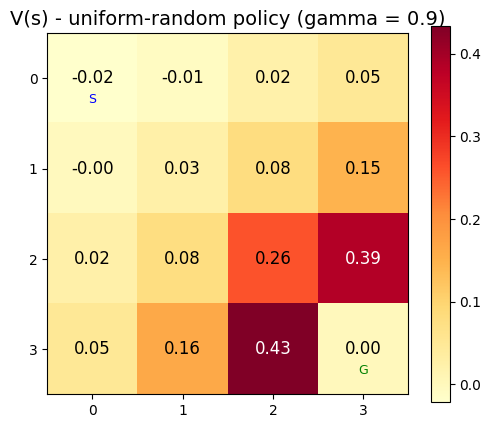

In [19]:
rng_vs = np.random.default_rng(42)
def random_policy_vs(state):
    return rng_vs.integers(0, SimpleGridMDP.N_ACTIONS)

env_vs = SimpleGridMDP()
V_random = estimate_state_values(env_vs, random_policy_vs, gamma=0.9, n_episodes=500)
plot_state_values(V_random, title="V(s) - uniform-random policy (gamma = 0.9)")

## 方策の比較

ランダム方策と、ゴールに向かう「賢い方策」で $V(s)$ がどう変わるか比較します。

**ゴール指向方策**: 状態 $(r, c)$ から、ゴール $(3, 3)$ へ近づく行動を選びます。
- ゴールより上にいれば下へ (`2`)、ゴールより左にいれば右へ (`1`)
- 行と列の両方で差がある場合はランダムに選択

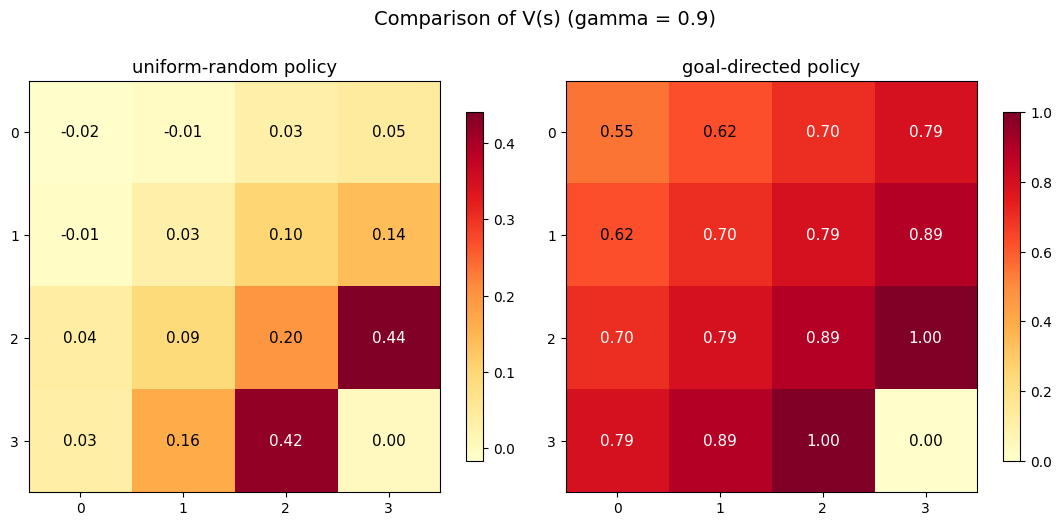

uniform-random policy — V(0,0) = -0.0164
goal-directed policy — V(0,0) = 0.5495


In [21]:
def goal_directed_policy(state):
    '''ゴール (3,3) に向かう簡単な方策。'''
    r, c = state
    candidates = []
    if r < 3:
        candidates.append(2)  # 下
    if c < 3:
        candidates.append(1)  # 右
    if r > 3:
        candidates.append(0)  # 上
    if c > 3:
        candidates.append(3)  # 左
    if len(candidates) == 0:
        return 0
    return candidates[np.random.randint(len(candidates))]

env_cmp = SimpleGridMDP()

rng_cmp = np.random.default_rng(123)
def random_policy_cmp(state):
    return rng_cmp.integers(0, SimpleGridMDP.N_ACTIONS)

V_rand = estimate_state_values(env_cmp, random_policy_cmp, gamma=0.9, n_episodes=500)
V_goal = estimate_state_values(env_cmp, goal_directed_policy, gamma=0.9, n_episodes=500)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, V, title in zip(axes, [V_rand, V_goal],
                         ["uniform-random policy", "goal-directed policy"]):
    grid = V.reshape(4, 4)
    im = ax.imshow(grid, cmap="YlOrRd", origin="upper")
    for r in range(4):
        for c in range(4):
            val = grid[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=11, color="black" if val < grid.max()*0.7 else "white")
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Comparison of V(s) (gamma = 0.9)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"uniform-random policy — V(0,0) = {V_rand[0]:.4f}")
print(f"goal-directed policy — V(0,0) = {V_goal[0]:.4f}")

### 確認問題

- なぜゴール指向方策の方が $V(s)$ が高いのでしょうか？
- ゴールに近い状態ほど $V(s)$ が高くなっていますか？ なぜでしょうか？

## $\gamma$ による $V(s)$ の変化

割引率 $\gamma$ を変えると状態価値がどう変わるか確認しましょう。

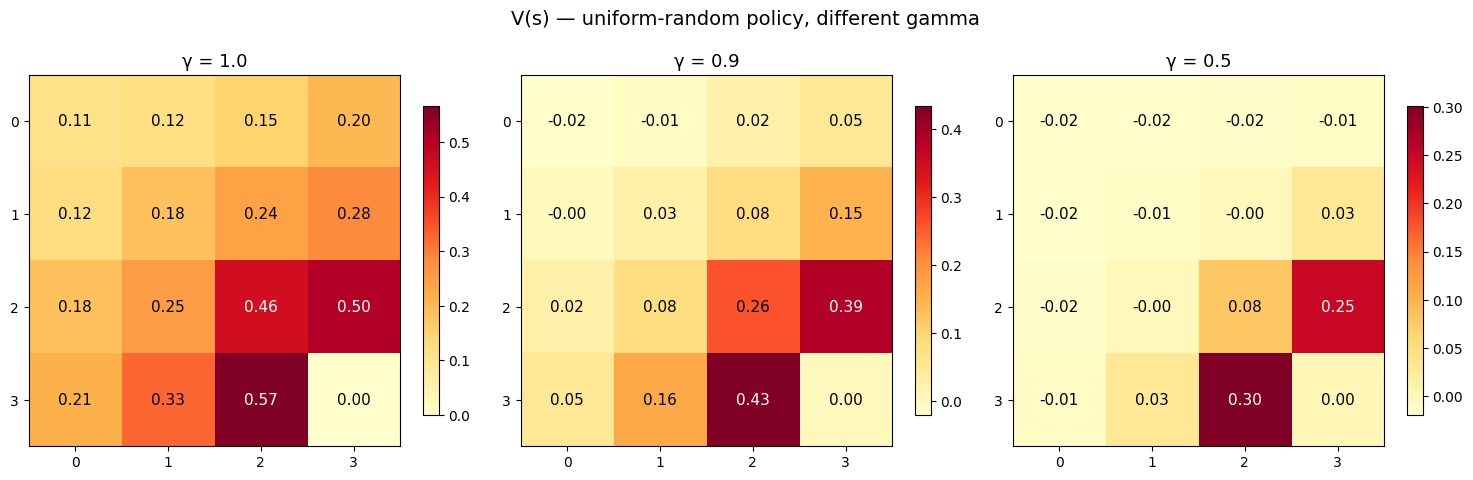

In [22]:
env_gamma = SimpleGridMDP()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, gamma in zip(axes, [1.0, 0.9, 0.5]):
    rng_g = np.random.default_rng(42)
    def _rp(state, _rng=rng_g):
        return _rng.integers(0, SimpleGridMDP.N_ACTIONS)
    V = estimate_state_values(env_gamma, _rp, gamma=gamma, n_episodes=500)
    grid = V.reshape(4, 4)
    im = ax.imshow(grid, cmap="YlOrRd", origin="upper")
    for r in range(4):
        for c in range(4):
            val = grid[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=11, color="black" if val < grid.max()*0.7 else "white")
    ax.set_title(f"γ = {gamma}", fontsize=13)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("V(s) — uniform-random policy, different gamma", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 振り返り・考察

以下の問いについて考え、レポートに記述してください。

1. **バンディット問題と MDP の最も大きな違いは何か？**

2. **state, action, reward, next_state は、この notebook のどの変数に対応するか？**

3. **reward（即時報酬）と return（累積報酬）はどう違うか？**

4. **$\gamma$ を小さくすると何が起きるか？ ヒートマップはどう変化したか？**

5. **$V(s)$ は何を表すか？ 日本語で1文で説明せよ。**

6. **この gridworld 環境はマルコフ的と言えるか？ その理由は？**
   ヒント：マルコフ性とは「現在の状態だけで次の状態と報酬が決まり、
   過去の状態履歴に依存しない」性質です。

---

### 次回予告

第4回では、**Bellman 方程式** と **動的計画法（Dynamic Programming）** を扱います。
「今の価値は、今の報酬と次の状態の価値で書ける」ことを理解するのがゴールです。